In [1]:
# Importación de Librerías principales
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [2]:
# Importación de Librerías de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report

In [3]:
# Definir ruta de trabajo
os.chdir(r"C:\Users\Nefi\OneDrive\Documentos\09-EBAC\EBACMX-DATA-ANALYST\Referencias")

# Cargar datos
df = pd.read_csv("bank-additional-full.csv", sep=";")

In [4]:
# Visualizar primeras filas
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [5]:
# Calcular skewness de variables numéricas
skewness = df.select_dtypes(include=np.number).skew()

print(skewness.sort_values(ascending=False))

campaign          4.762507
previous          3.832042
duration          3.263141
age               0.784697
cons.conf.idx     0.303180
cons.price.idx   -0.230888
euribor3m        -0.709188
emp.var.rate     -0.724096
nr.employed      -1.044262
pdays            -4.922190
dtype: float64


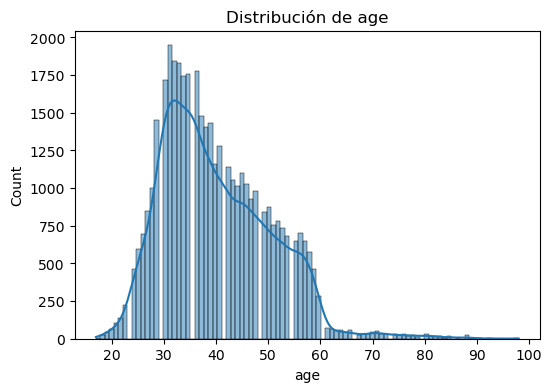

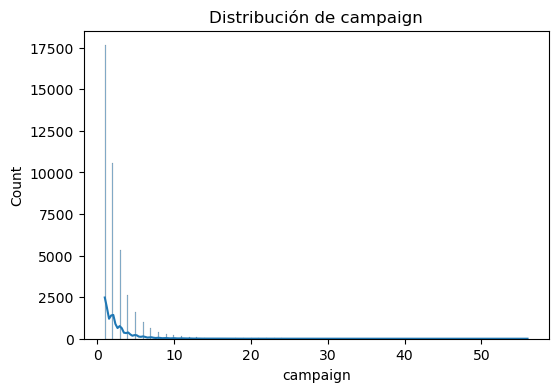

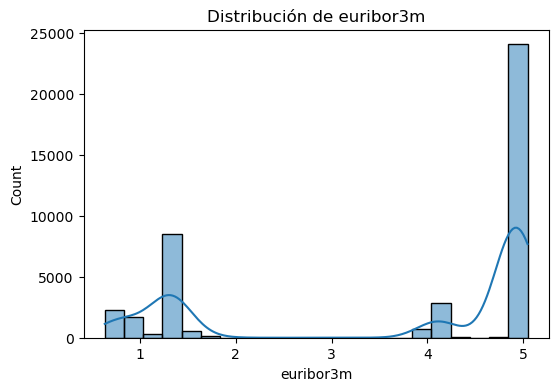

In [ ]:
# Visualización de algunas variables
numeric_cols = ['age','campaign','euribor3m']

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribución de {col}')
    plt.show()

In [7]:
# Convertir variables categóricas en variables dummy
df = pd.get_dummies(df, drop_first=True)

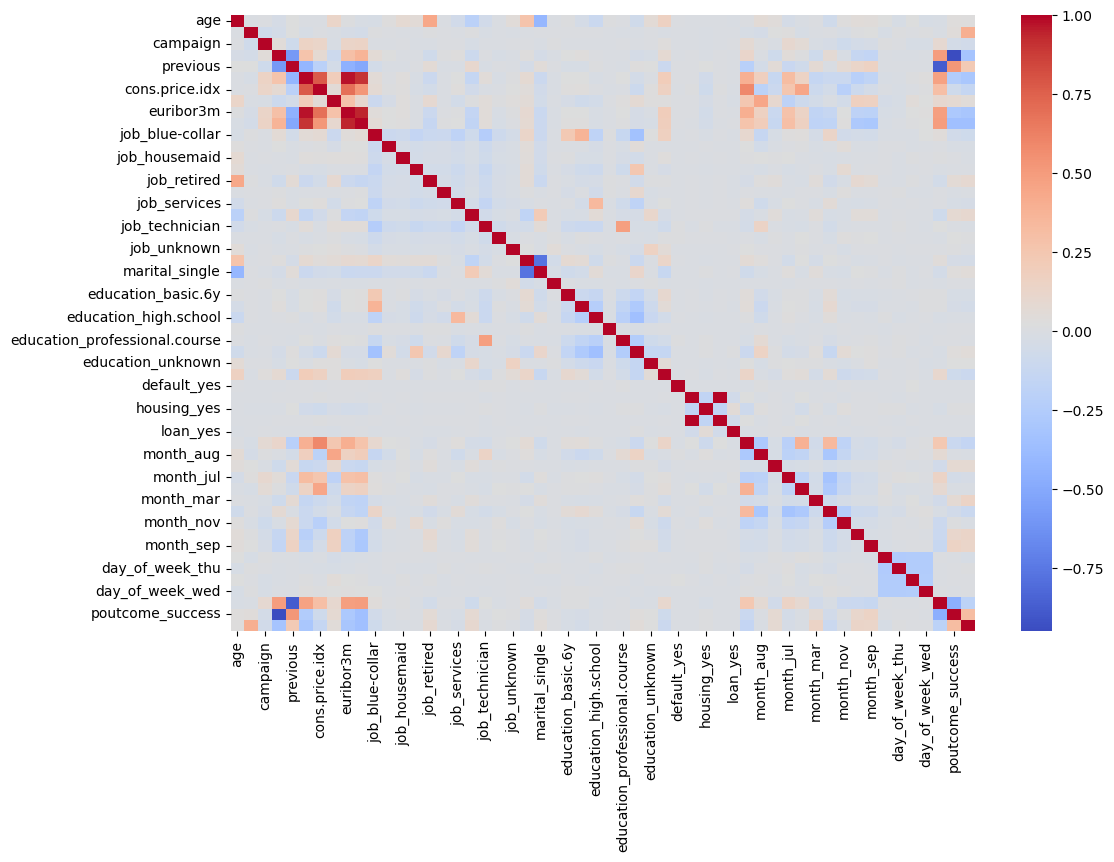

In [8]:
# Matriz de correlación
corr_matrix = df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.show()

In [9]:
# Seleccionar solo el triángulo superior
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

In [11]:
# Variables con alta correlación
to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]

print("Variables eliminadas:", to_drop)

Variables eliminadas: ['euribor3m', 'nr.employed', 'loan_unknown']


In [12]:
# Eliminar variables
df = df.drop(columns=to_drop)

In [13]:
# Variable objetivo
y = df['y_yes']

# Variables predictoras
X = df.drop('y_yes', axis=1)

In [14]:
# Estandarización de variables
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Convertir nuevamente a DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [15]:
# División de dataset 70-30
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.3,
    random_state=42
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (28831, 50)
Test set: (12357, 50)


In [16]:
# Creación de modelo de regresión logística
model = LogisticRegression(max_iter=1000)

In [17]:
# Entrenar modelo
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [18]:
# Predicciones
y_pred = model.predict(X_test)

In [19]:
# Calcular matriz de Confusión
cm = confusion_matrix(y_test, y_pred)

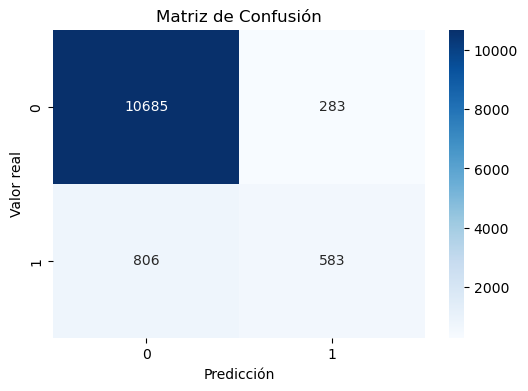

In [21]:
# Visualización
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de Confusión")

plt.show()

In [22]:
# Métricas del modelo
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.9118718135469774
Precision: 0.6732101616628176
Recall: 0.4197264218862491
F1 Score: 0.5170731707317073


In [23]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.93      0.97      0.95     10968
        True       0.67      0.42      0.52      1389

    accuracy                           0.91     12357
   macro avg       0.80      0.70      0.73     12357
weighted avg       0.90      0.91      0.90     12357

